# Assignment 2: Exploratory Data Analysis and Preprocessing for Predictive Modeling

**Dataset:** [Impact of Remote Work on Mental Health](https://www.kaggle.com/datasets/waqi786/remote-work-and-mental-health)

**Model Used:** Random Forest



#**1. Import Key Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier,  plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder , RobustScaler
!pip install ydata-profiling
!pip install ipywidgets
from ydata_profiling import ProfileReport
import plotly.express as px

#**2. Read / Load Data**

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/NSCC-ITC-Fall2025-DBAS5115-700-MCr/assignment-2-emppacs/refs/heads/main/Impact_of_Remote_Work_on_Mental_Health.csv?token=GHSAT0AAAAAADPKGJHXDZULOBDO3FGSFZ422JVC44A")
print(df.head())

  Employee_ID  Age      Gender           Job_Role    Industry  \
0     EMP0001   32  Non-binary                 HR  Healthcare   
1     EMP0002   40      Female     Data Scientist          IT   
2     EMP0003   59  Non-binary  Software Engineer   Education   
3     EMP0004   27        Male  Software Engineer     Finance   
4     EMP0005   49        Male              Sales  Consulting   

   Years_of_Experience Work_Location  Hours_Worked_Per_Week  \
0                   13        Hybrid                     47   
1                    3        Remote                     52   
2                   22        Hybrid                     46   
3                   20        Onsite                     32   
4                   32        Onsite                     35   

   Number_of_Virtual_Meetings  Work_Life_Balance_Rating Stress_Level  \
0                           7                         2       Medium   
1                           4                         1       Medium   
2             

#**3. Exploratory Data Analysis (EDA) and Visualization**

####***3a. Check for Missing Values***

In [3]:
# Initial Null Check:
print(df.info())

# check data shape:
print("\n\n")
print(f"="*50)
print(f"Data Shape: {df.shape}")
print(f"="*50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Employee_ID                        5000 non-null   object
 1   Age                                5000 non-null   int64 
 2   Gender                             5000 non-null   object
 3   Job_Role                           5000 non-null   object
 4   Industry                           5000 non-null   object
 5   Years_of_Experience                5000 non-null   int64 
 6   Work_Location                      5000 non-null   object
 7   Hours_Worked_Per_Week              5000 non-null   int64 
 8   Number_of_Virtual_Meetings         5000 non-null   int64 
 9   Work_Life_Balance_Rating           5000 non-null   int64 
 10  Stress_Level                       5000 non-null   object
 11  Mental_Health_Condition            3804 non-null   object
 12  Access

*to further check if there are missing values:*

In [6]:
missing_data = df.isnull().sum()
print(missing_data)
print("\n\n")
print(f"="*50)
print(f"Missing Data:")
print(f"="*50)
print(missing_data[missing_data > 0])

Employee_ID                             0
Age                                     0
Gender                                  0
Job_Role                                0
Industry                                0
Years_of_Experience                     0
Work_Location                           0
Hours_Worked_Per_Week                   0
Number_of_Virtual_Meetings              0
Work_Life_Balance_Rating                0
Stress_Level                            0
Mental_Health_Condition              1196
Access_to_Mental_Health_Resources       0
Productivity_Change                     0
Social_Isolation_Rating                 0
Satisfaction_with_Remote_Work           0
Company_Support_for_Remote_Work         0
Physical_Activity                    1629
Sleep_Quality                           0
Region                                  0
dtype: int64



Missing Data:
Mental_Health_Condition    1196
Physical_Activity          1629
dtype: int64


*from the result, we can see two fields that has missing values: Mental_Health_Condition (1196) and Physical_Activity (1629)*





*We will deal with it later, for now, let's visualize the data distributions, relationships, and outliers using Seaborn and Plotly*

***Visualize the Missing Values***

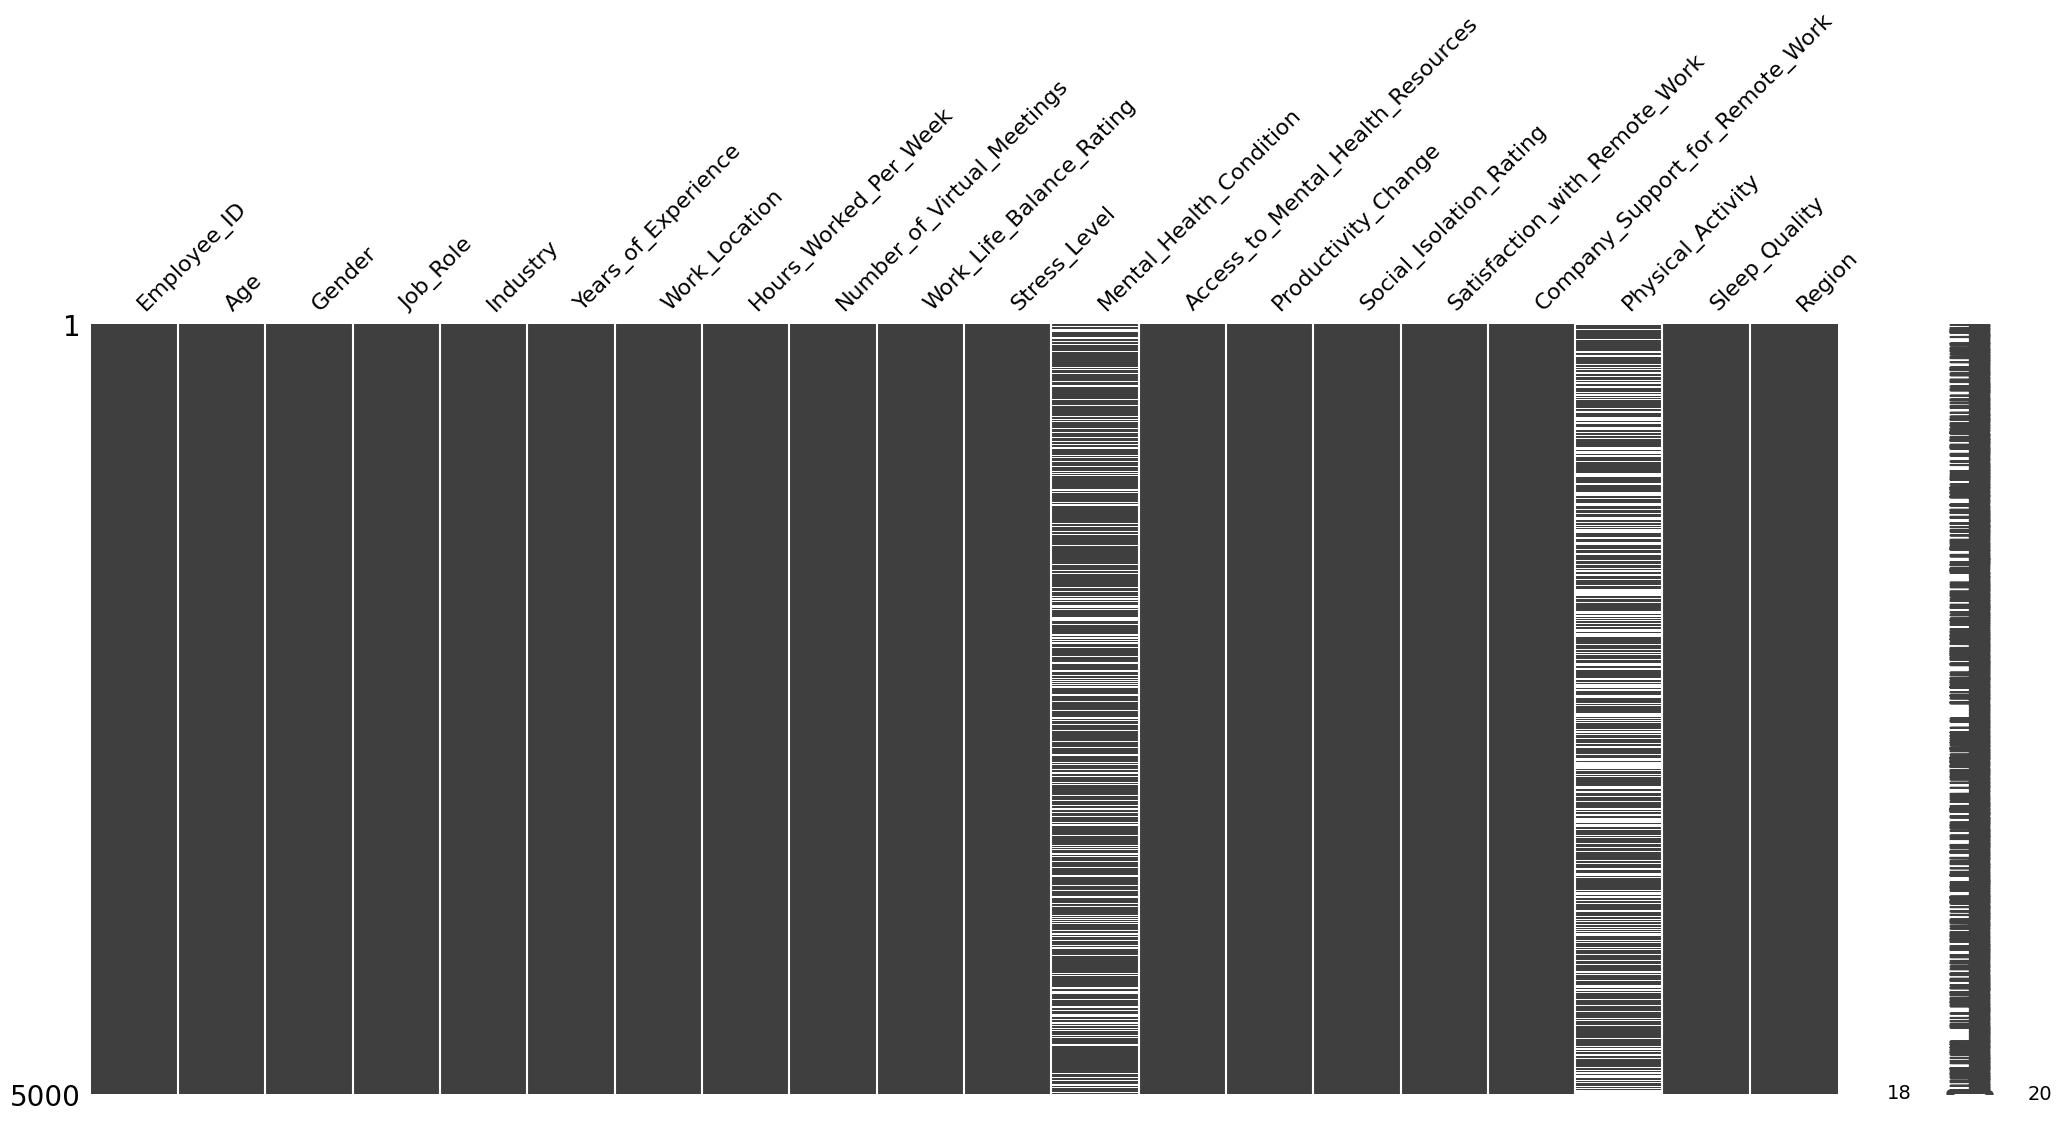

In [5]:
import missingno as msno
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'png'

msno.matrix(df)
plt.show()

####***3b. YData profiling***

In [ ]:
profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)
#profile.to_file("pandas_profiling_report.html")
profile.to_notebook_iframe()

####***3c. Visualize Data Distribution***

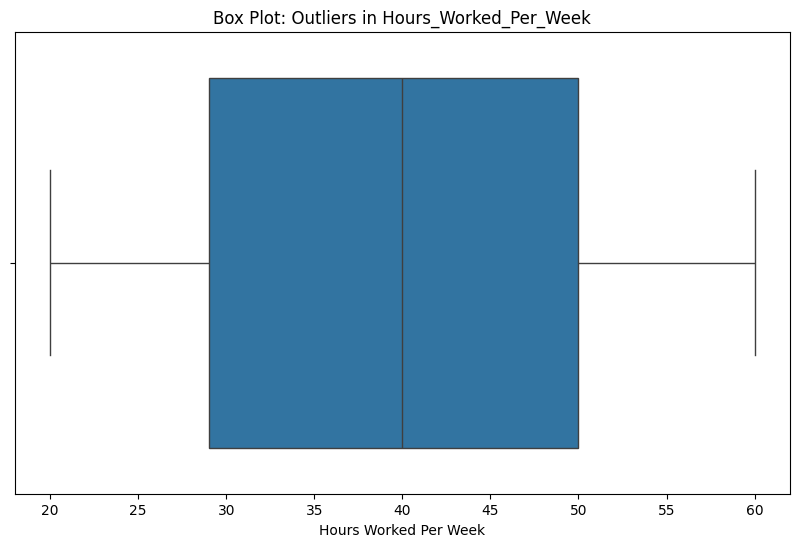

In [6]:
#1. Box Plot for Outliers in Hours_Worked_Per_Week

plt.figure(figsize=(10,6))
sns.boxplot(x=df['Hours_Worked_Per_Week'])
plt.title("Box Plot: Outliers in Hours_Worked_Per_Week")
plt.xlabel("Hours Worked Per Week")
plt.show()

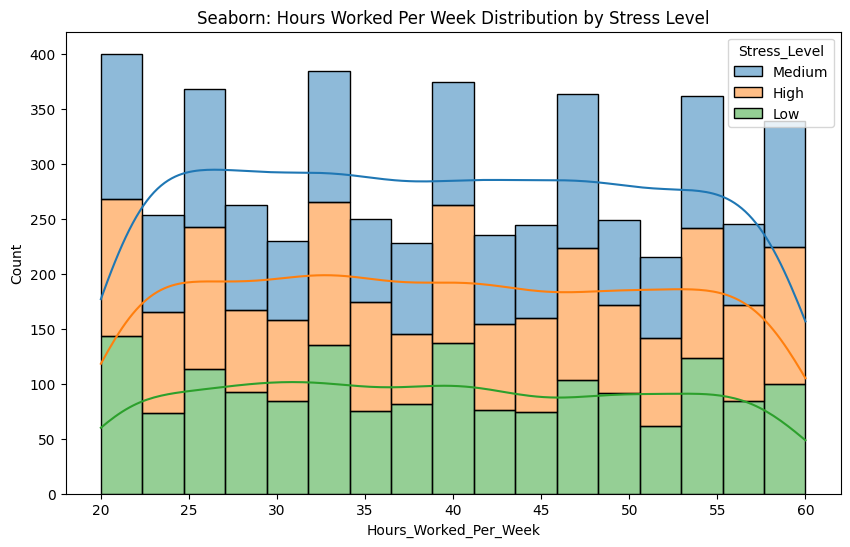

In [7]:
# 2. Histogram: Hours_Worked_Per_Week Distribution by Stress Level
plt.figure(figsize=(10, 6))

# Use 'hue' to separate the distributions by the target variable
sns.histplot(
    data=df,
    x='Hours_Worked_Per_Week',
    hue='Stress_Level',
    multiple='stack', # 'stack' or 'dodge' are good options
    kde=True
)
plt.title("Seaborn: Hours Worked Per Week Distribution by Stress Level")
plt.xlabel("Hours_Worked_Per_Week")
plt.show()

In [8]:
# 3. Plotly Density Heatmap: Relationship between Hours Worked and Work Life Balance Rating vs. Stress Level
# Use a density heatmap to show where the points are most frequent
fig = px.density_heatmap(
    df,
    x='Hours_Worked_Per_Week',
    y='Work_Life_Balance_Rating',
    facet_col='Stress_Level',
    title='Density of Stress Levels Across Hours and WLB Rating',
    template='plotly_dark'
)

fig.show()

#**4. Defining X and y (Features and Target)**

In [9]:
# target column is Stress_Level
target_col = 'Stress_Level'

# Drop not relevant columns
df = df.drop(columns=['Employee_ID'])

# split into X and y: X will be all columns EXCEPT the identifier and the target
X = df.drop(target_col, axis=1)
y = df[target_col]

print(f"Target variable defined as: {y.name}")
print(f"X (Features) shape: {X.shape}")

Target variable defined as: Stress_Level
X (Features) shape: (5000, 18)


#**5. Splitting the Data**

In [10]:
# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Stratify ensures that the proportion of Low/Medium/High stress is the same in both splits

print(f"="*50)
print("Data Splitting Complete!")
print(f"="*50)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


Data Splitting Complete!
X_train shape: (4000, 18)
X_test shape: (1000, 18)


#**6. Preprocessing**

In [11]:
# Identify Numeric and Categorical features
NUMERIC_FEATURES = ['Age', 'Years_of_Experience', 'Hours_Worked_Per_Week', 'Number_of_Virtual_Meetings', 'Work_Life_Balance_Rating', 'Social_Isolation_Rating']
CATEGORICAL_FEATURES = ['Gender', 'Job_Role', 'Industry', 'Work_Location', 'Mental_Health_Condition', 'Access_to_Mental_Health_Resources', 'Productivity_Change', 'Satisfaction_with_Remote_Work', 'Company_Support_for_Remote_Work', 'Physical_Activity', 'Sleep_Quality', 'Region']


####***6a. Numeric Pipeline: Handles Scaling and Numeric Nulls***

In [12]:
# create pipeline for numeric nulls
numeric_pipeline = Pipeline(steps=[

    # Handles null values: Use median for robustness against outliers
    ('imputer' , SimpleImputer(strategy='median')),

    # normalize and scale numeric values
    ('scaler', RobustScaler())

]

)

####***6b. Categorical Pipeline: (Handles Encoding and Categorical Nulls)***

In [13]:
# create pipeline for categorical nulls
categorical_pipeline = Pipeline(steps=[

    # Handles null values: Impute with 'Unknown' to preserve missingness information
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),

    # Encodes categorical features into numerical format
    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

####***6c. Combine both preprocessed numerical and categorical data using Column Transformer module***

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, NUMERIC_FEATURES),
        ('cat', categorical_pipeline, CATEGORICAL_FEATURES)
    ]
)

####***6d. Integrate the Preprocessed Features and Random Forest Classifier Using Pipelines***

In [20]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, min_samples_split=5, max_depth=12, random_state=42))
])

print("Final Modeling Pipeline Successfully Constructed and Ready for Training.")

Final Modeling Pipeline Successfully Constructed and Ready for Training.


#**7. Model Construction and Evaluation**

In [21]:
print(f"="*50)
print("Training Random Forest Pipeline...")
print(f"="*50)

clf.fit(X_train, y_train)

Training Random Forest Pipeline...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Age', 'Years_of_Experience',
                                                   'Hours_Worked_Per_Week',
                                                   'Number_of_Virtual_Meetings',
                                                   'Work_Life_Balance_Rating',
                                                   'Social_Isolation_Rating']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Job_Role',
                                                   'Industry', 'Work_Location',
                                                   'Mental_Health_Condition',
                                                   'Access_to_Mental_Health_Resources',
                                                   'Productivity_Change',
                                                   'Satisfaction_with_Remote_Work',
                                                   'Company_Support_for_Remote_Work',
                                                   'Physical_Activity',
                                                   'Sleep_Quality',
                                                   'Region'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=12, min_samples_split=5,
                                        random_state=42))])

In [22]:
# Prediction
y_pred = clf.predict(X_test)

# Model Performance
print(f"="*50)
print("MODEL PERFORMANCE: RANDOM FOREST CLASSIFIER")
print(f"="*50)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Confusion matrix
cm = (confusion_matrix(y_test, y_pred))
print("\nConfusion Matrix:")
print(cm)

MODEL PERFORMANCE: RANDOM FOREST CLASSIFIER
Accuracy: 0.363

Classification Report:
              precision    recall  f1-score   support

        High       0.36      0.39      0.37       337
         Low       0.35      0.33      0.34       329
      Medium       0.38      0.37      0.38       334

    accuracy                           0.36      1000
   macro avg       0.36      0.36      0.36      1000
weighted avg       0.36      0.36      0.36      1000


Confusion Matrix:
[[130 112  95]
 [110 108 111]
 [119  90 125]]


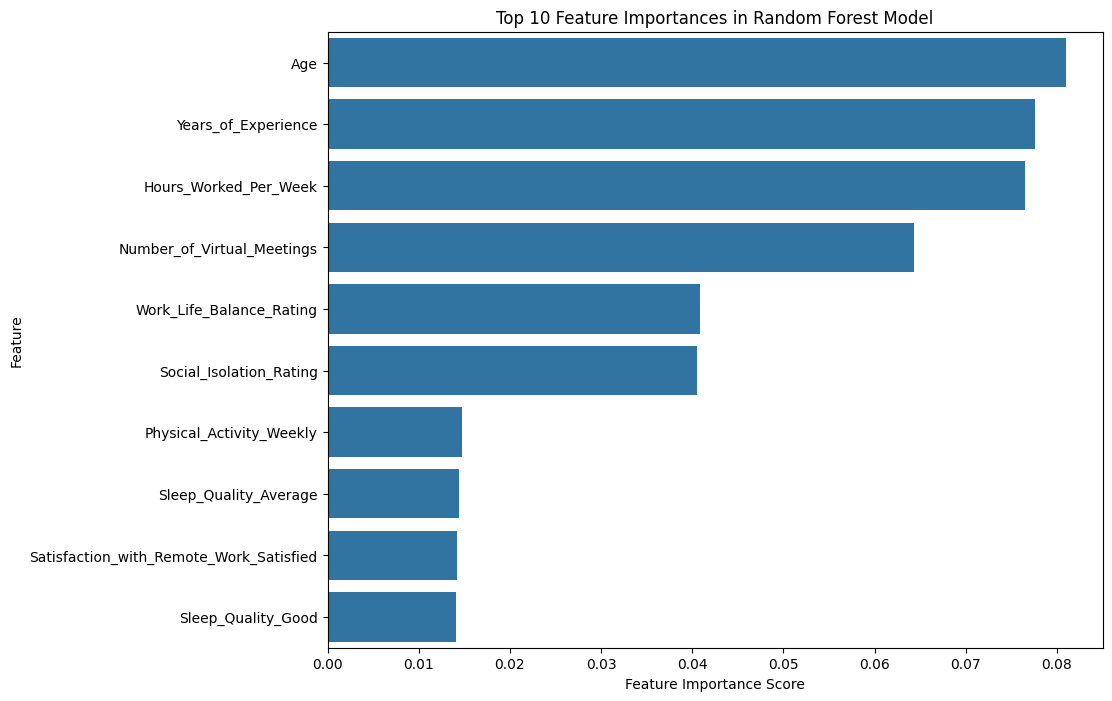

In [23]:
# feature importance

final_model = clf.named_steps['classifier']
preprocessor_fitted = clf.named_steps['preprocessor']


importances = final_model.feature_importances_


numeric_features_out = NUMERIC_FEATURES
onehot_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
categorical_features_out = list(onehot_encoder.get_feature_names_out(CATEGORICAL_FEATURES))


feature_names_out = numeric_features_out + categorical_features_out


feature_importance_df = pd.DataFrame({
    'Feature': feature_names_out,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 6. Plotting the Top 15 Features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10),
)
plt.title('Top 10 Feature Importances in Random Forest Model')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.show()

In [18]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [8, 12, None],
    'classifier__min_samples_split': [5, 10],
}

# Integrate GridSearchCV into the final pipeline setup
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5, # Use 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1 # Use all processors
)

# Train the Grid Search (This takes much longer than a simple .fit)
print("Starting GridSearchCV for Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)

# Use the best model found by the search
best_model = grid_search.best_estimator_

# Evaluation using the best model
y_pred_tuned = best_model.predict(X_test)

print("\n" + "="*50)
print("MODEL PERFORMANCE: RANDOM FOREST CLASSIFIER (TUNED)")
print("="*50)
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Tuned Accuracy on Test Set: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))

Starting GridSearchCV for Hyperparameter Tuning...

MODEL PERFORMANCE: RANDOM FOREST CLASSIFIER (TUNED)
Best Parameters Found: {'classifier__max_depth': 12, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Tuned Accuracy on Test Set: 0.3630

Classification Report (Tuned Model):
              precision    recall  f1-score   support

        High       0.36      0.39      0.37       337
         Low       0.35      0.33      0.34       329
      Medium       0.38      0.37      0.38       334

    accuracy                           0.36      1000
   macro avg       0.36      0.36      0.36      1000
weighted avg       0.36      0.36      0.36      1000

